# 🌗 Dynamic Range Alignment

This notebook (will) implement dynamic range alignment for each pair of digital and film images.
Goal: To line up the grey-levels/luminance of each pair of images so that the model does not to adjust luminance levels

In [23]:
import autorootcwd

In [24]:
import numpy as np
import cv2 as cv

from matplotlib import pyplot as plt

In [25]:
from typing import List, Tuple, Union

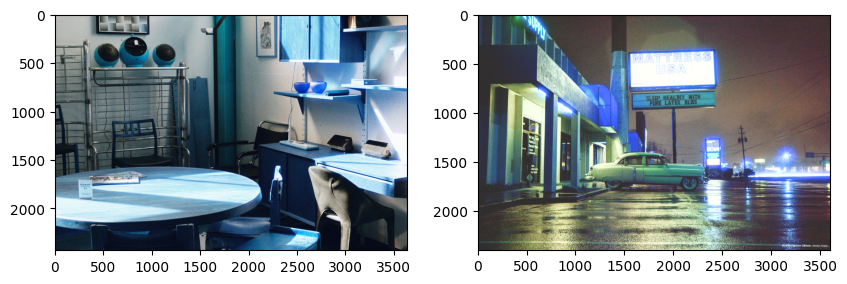

In [29]:
# Load image example
im1 = cv.imread('imgs/table_cafe_film.JPG')
lab_image = cv.cvtColor(im1, cv.COLOR_BGR2LAB)

im2 = cv.imread('imgs/cinestill-800t.jpg')


# im2 = cv.imread('imgs/table_cafe_digital.ARW')



def align_luminance(im1, im2):
    """
    Align the luminance of two images
    """
    # Convert to LAB
    lab1 = cv.cvtColor(im1, cv.COLOR_BGR2LAB)
    lab2 = cv.cvtColor(im2, cv.COLOR_BGR2LAB)

    # Split into channels
    l1, a1, b1 = cv.split(lab1)
    l2, a2, b2 = cv.split(lab2)

    # Align the luminance of the two images
    l2 = cv.add(l2, np.mean(l1) - np.mean(l2))

    # Merge the channels back together
    lab2 = cv.merge((l2, a2, b2))

    # Convert back to BGR
    return cv.cvtColor(lab1, cv.COLOR_LAB2BGR), cv.cvtColor(lab2, cv.COLOR_LAB2BGR)

# call function on example images
aligned1, aligned2 = align_luminance(im1, im2)

# Display the two images

fig, axs = plt.subplots(ncols=2, figsize=(10, 5))
axs[0].imshow(aligned1)
axs[1].imshow(aligned2)
